In [1]:
#!pip install osmnx --user
#!pip install folium --user
# !pip install folium matplotlib mapclassify
import h3
import re
import os 
import osmnx
import geopandas as gpd 
import pandas as pd
import matplotlib.pyplot as plt 
import folium
from pyhive import presto
from datetime import date

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 600)

import warnings
warnings.filterwarnings("ignore")

In [2]:
## Connection
connection = presto.connect(
        host='presto-gateway.serving.data.production.internal',
        port=80,
        protocol='http',
        catalog='hive',
        username='manoj.ravirajan@rapido.bike'
)

In [3]:
city_name = 'Chennai'

In [4]:
city_cluster_hex = f"""
    select 
        city, cluster_original cluster, hex_id, resolution  
    from 
        datasets.city_cluster_hex 
    where 
        city = '{city_name}'
        and resolution = 8
"""

df_city_cluster_hex = pd.read_sql(city_cluster_hex, connection)
df_city_cluster_hex

,city,cluster,hex_id,resolution
0,Chennai,Madhavaram,88618eb223fffff,8
1,Chennai,,88618c4283fffff,8
2,Chennai,Padianallur,88618eb1c3fffff,8
3,Chennai,,88618c720dfffff,8
4,Chennai,Tiruvottiyur,88618eb36bfffff,8
...,...,...,...,...
1633,Chennai,Manapakkam,88618c4c57fffff,8
1634,Chennai,Nungambakkam,88618c489bfffff,8
1635,Chennai,Vanagaram Fish Market,88618c4dddfffff,8
1636,Chennai,Semmancheri,88618c4741fffff,8


In [5]:
city_hex_id_list = df_city_cluster_hex['hex_id'].tolist()

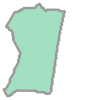

In [6]:
from shapely.geometry import Polygon

def cell_to_shapely(city_hex_id_list):
    #coords = h3.h3_to_geo_boundary(city_hex_id_list)
    coords = tuple(h3.h3_set_to_multi_polygon(city_hex_id_list)[0][0])
    flipped = tuple(coord[::-1] for coord in coords)
    return Polygon(flipped)

cell_to_shapely(city_hex_id_list)

In [7]:
aoi_gdf = cell_to_shapely(city_hex_id_list)

In [8]:

# AOI = ['Chennai District, India', 'Tambaram']
# aoi_gdf = osmnx.geocode_to_gdf(cell_to_shapely(city_hex_id_list))
aoi_gdf
#plot area of interest
basemap = aoi_gdf.explore(color='lightblue')
basemap

AttributeError: 'Polygon' object has no attribute 'explore'

In [ ]:
aoi_gdf

In [ ]:
# !pip install h3
import shapely, h3
from shapely.geometry.polygon import Polygon
from shapely.geometry.multipolygon import MultiPolygon
from shapely.geometry.point import Point
from shapely.geometry.linestring import LineString
from shapely.geometry import mapping

def geometry_to_hex(geometry,hex_resolution):
    hex_12_ids=set()
    
    try:
    
        if type(geometry) == MultiPolygon:
            geojson = [shapely.geometry.mapping(item) for item in geometry]
            hex_id = [h3.polyfill(item,hex_resolution) for item in geojson]
            for item in hex_id:
                hex_12_ids=hex_12_ids.union(item)

        elif type(geometry) == shapely.geometry.polygon.Polygon:
            geojson = shapely.geometry.mapping(geometry)
            hex_id = h3.polyfill(geojson,hex_resolution)
            hex_12_ids=hex_12_ids.union(hex_id)

        elif type(geometry) == Point:
            hex_id=h3.geo_to_h3(geometry.x, geometry.y, hex_resolution)
            hex_12_ids={hex_id}
        
        for item in hex_12_ids:
            hex_12_ids=hex_12_ids.union(h3.k_ring(item,1))
        return(hex_12_ids)
    
    except:
        pass

In [ ]:
osmnx.geometries_from_polygon(polygon = aoi_gdf.geometry.geometry.unary_union,
                                     tags = {'landuse':'residential'}).explore(color = 'green',m= basemap)

### Polyline

In [ ]:
import polyline

In [ ]:
start_date = '20231003'
end_date = '20231003'
city = 'Chennai'
service = 'Auto'

In [ ]:
order_logs_snapshot = f"""

WITH service_mapping AS (
    
    SELECT 
        city_display_name,
        service_detail_id,
        service_level
    FROM 
        datasets.service_mapping
            
    WHERE 
        city_display_name = '{city}'
        AND service_level = '{service}'
    ),
    
    orders_tbl AS (
    
    SELECT
            orderdate,
            city,
            service_name,
            estimate_id, 
            order_id,
            order_amount,
            reason,
            fe_re_type,
            fe_re_diff_amount,
            polyline,
            u.id_array as fare_estimate_id
        FROM
            (
            SELECT   
                city_name as city,
                service_obj_service_name as service_name,
                order_id,
                date_format(from_unixtime(epoch / 1000, 'Asia/Kolkata'), '%Y-%m-%d') AS orderdate,
                epoch,
                estimate_id,
                estimate_ids,
                polyline,
                amount as order_amount,
                fare_recalculated_reason reason,
                fare_recalculated_type AS fe_re_type,
                fare_recalculated_diff_amount AS fe_re_diff_amount,
                cast(json_parse(estimate_ids) as array<varchar>) AS id_array
            FROM
                orders.order_logs_snapshot ols 
            JOIN 
                service_mapping map
                ON ols.service_detail_id = map.service_detail_id
            WHERE
                yyyymmdd >= '{start_date}'
                AND yyyymmdd <= '{end_date}' 
                AND order_status in ('dropped')
                AND spd_fraud_flag != True
            ) as t
        CROSS JOIN UNNEST(t.id_array) AS u(id_array)
    ),
    
    fare_estimate AS (
    
    SELECT 
        yyyymmdd,
        city,
        service_name,
        user_id,
        fare_estimate_id,
        polyline,
        api_context,
        cast(final_amount AS double) AS fe_amount,
        price_increase_strategy,
        epoch
        
    FROM 
        pricing.fare_estimates_enriched fee 
    JOIN 
        service_mapping map
        ON fee.service_detail_id = map.service_detail_id
    WHERE 
        yyyymmdd >= '{start_date}'
        AND yyyymmdd <= '{end_date}' 
    ),
    
merged_tbl as (

    SELECT  
        o.orderdate,
        o.service_name,
        o.order_id,
        o.estimate_id,
        price_increase_strategy,
        api_context,
        o.fare_estimate_id,
        o.reason,
        row_number() over (partition by o.estimate_id order by f.epoch asc)  as updated_seq,
        fe_amount,
        o.order_amount,
        fe_re_type,
        fe_re_diff_amount,
        o.polyline z_polyline, 
        f.polyline a_polyline
    FROM
        orders_tbl o
    INNER JOIN 
        fare_estimate f
        ON o.fare_estimate_id = f.fare_estimate_id
        AND o.service_name = f.service_name
)
    
    SELECT
            *
    FROM 
        merged_tbl
    WHERE 
        updated_seq = 1

"""

df_order_logs_snapshot = pd.read_sql(order_logs_snapshot, connection)
df_order_logs_snapshot

In [ ]:
polyline_list = df_order_logs_snapshot['z_polyline'].tolist()
polyline_list[0]

In [ ]:
coordinates = polyline.decode(polyline_list[0])

In [ ]:
coordinates[0:5]

In [ ]:
len(coordinates)

FE  - Polyline -> co-or -> hex_id(low hex level) -> route with associated hex  <br>
Drop  - Polyline -> co-or -> hex_id(low hex level) -> route with associated hex <br>

Overlap of hex's b/w FE & Drop <br>

### Test case

https://profiles.rapido.bike/order/651bb3ed54c54371d2ffe863

In [ ]:
df_analysis_sample = df_order_logs_snapshot[df_order_logs_snapshot['order_id'].isin(['651bb3ed54c54371d2ffe863'])]
df_analysis_sample

In [ ]:
df = df_analysis_sample

### Manual work

In [31]:
import pandas as pd
import polyline
from shapely.geometry import LineString
import h3

# Assuming df is your DataFrame and 'a_polyline' and 'z_polyline' are the columns with polyline data
polyline_data_1 = df['a_polyline'].tolist()
polyline_data_2 = df['z_polyline'].tolist()

# Function to decode polyline data to coordinates
def decode_polyline(polyline_str):
    return polyline.decode(polyline_str)

# Function to create Geo Line from coordinates
def create_geo_line(coordinates):
    return LineString(coordinates)

# Function to map hex IDs for a given set of coordinates
def map_to_hex_ids(coordinates, resolution):
    hex_ids = [h3.geo_to_h3(lat, lon, resolution) for lon, lat in coordinates]
    return hex_ids

# Specify the H3 resolution (adjust as needed)
h3_resolution = 8

# Applying the functions to the first set of polyline data
coordinates_list_1 = [decode_polyline(polyline_str) for polyline_str in polyline_data_1]
geo_lines_1 = [create_geo_line(coords) for coords in coordinates_list_1]
hex_ids_list_1 = [map_to_hex_ids(line.coords, h3_resolution) for line in geo_lines_1]

# Applying the functions to the second set of polyline data
coordinates_list_2 = [decode_polyline(polyline_str) for polyline_str in polyline_data_2]
geo_lines_2 = [create_geo_line(coords) for coords in coordinates_list_2]
hex_ids_list_2 = [map_to_hex_ids(line.coords, h3_resolution) for line in geo_lines_2]

# Adding new columns to the DataFrame with hex IDs
df['hex_ids_1'] = hex_ids_list_1
df['hex_ids_2'] = hex_ids_list_2

# Function to compare two sets of hex IDs
def compare_hex_ids(hex_ids_1, hex_ids_2):
    # Your comparison logic here
    # For example, you can check if there are common hex IDs, count differences, etc.
    common_hex_ids = set(hex_ids_1) & set(hex_ids_2)
    return common_hex_ids

# Applying the comparison function to each row
df['common_hex_ids'] = df.apply(lambda row: compare_hex_ids(row['hex_ids_1'], row['hex_ids_2']), axis=1)


In [32]:
df

,orderdate,service_name,order_id,estimate_id,price_increase_strategy,api_context,fare_estimate_id,reason,updated_seq,fe_amount,order_amount,fe_re_type,fe_re_diff_amount,z_polyline,a_polyline,hex_ids_1,hex_ids_2,common_hex_ids
14326,2023-10-03,Auto,651bb3ed54c54371d2ffe863,651bbd0be6181f02e82e4769,None,/fare/estimate,651bb3d73f94bb0214f70792,routeDiff,1,197.0,195.0,decrease,2.0,c`jnAcdohN}A?eGG[@QLXf@Pv@DpAGn@Mr@WtCWrE@`@Ht...,c`jnAcdohN}A?eGG[@QLXf@Pv@DpAGn@Mr@WtCWrE@`@Ht...,"[88015a6067fffff, 88015a6067fffff, 88015a6067f...","[88015a6067fffff, 88015a6067fffff, 88015a6067f...","{88015a61e9fffff, 88015a6061fffff, 88015a602df..."


In [52]:
df[['hex_ids_1','hex_ids_2','common_hex_ids']]

,hex_ids_1,hex_ids_2,common_hex_ids
14326,"[88015a6067fffff, 88015a6067fffff, 88015a6067f...","[88015a6067fffff, 88015a6067fffff, 88015a6067f...","{88015a61e9fffff, 88015a6061fffff, 88015a602df..."


In [57]:
hex_ids_list_1

[['88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6061fffff',
  '88015a6061fffff',
  '88015a6061fffff',
  '88015a6061fffff',
  '88015a6061fffff',
  '88015a6061fffff',
  '88015a6061fffff',
  '88015a6061fffff',
  '88015a6061fffff',
  '88015a6061fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067fffff',
  '88015a6067

In [5]:
polyline_list = ['c`jnAcdohN}A?eGG[@QLXf@Pv@DpAGn@Mr@WtCWrE@`@Ht@\z@tApBUNOUm@i@[c@Sa@_@qACy@LqBd@cFDcBI_AG]Wm@]m@QSWK{@WgB[eBOyAUM?cB[k@UcByAc@m@]o@g@oAO[c@m@c@_@cBaAiCq@_@EcACaBJmELwFGuBKi@EQEuC_@kFw@iD_A_KgC_OqDqAUmAKoEIiE?sBK_BQuCWmEo@{D}@{Am@kEqBcBaAuAi@wBa@yCc@oCi@yDw@iDm@{@Mm@C_D_@UOwAEsDUeAaATuANsAD}BCq@KQQMa@EeACkHCuA@}A?wOHyKI_G@kSTa@HyBLoCFiCLiA?UsBYeDW_Bq@kCe@kA_CiL}@uD[gAk@oC[HiA_H_@eBi@mDc@eC_@gBo@{EGU}@mH]kD]}GCM?k@DSG_BIgF@qC?cCDmBl@qLCU~A}N\kE^kDhAmHd@aDBUSuB}@UgE{AuAWiAE}ATy@F{@Ie@KoAi@o@Oa@EIJOAIO?Em@Q_AAeAHAIrAI']
polyline_list[0]

'c`jnAcdohN}A?eGG[@QLXf@Pv@DpAGn@Mr@WtCWrE@`@Ht@\\z@tApBUNOUm@i@[c@Sa@_@qACy@LqBd@cFDcBI_AG]Wm@]m@QSWK{@WgB[eBOyAUM?cB[k@UcByAc@m@]o@g@oAO[c@m@c@_@cBaAiCq@_@EcACaBJmELwFGuBKi@EQEuC_@kFw@iD_A_KgC_OqDqAUmAKoEIiE?sBK_BQuCWmEo@{D}@{Am@kEqBcBaAuAi@wBa@yCc@oCi@yDw@iDm@{@Mm@C_D_@UOwAEsDUeAaATuANsAD}BCq@KQQMa@EeACkHCuA@}A?wOHyKI_G@kSTa@HyBLoCFiCLiA?UsBYeDW_Bq@kCe@kA_CiL}@uD[gAk@oC[HiA_H_@eBi@mDc@eC_@gBo@{EGU}@mH]kD]}GCM?k@DSG_BIgF@qC?cCDmBl@qLCU~A}N\\kE^kDhAmHd@aDBUSuB}@UgE{AuAWiAE}ATy@F{@Ie@KoAi@o@Oa@EIJOAIO?Em@Q_AAeAHAIrAI'

In [6]:
coordinates = polyline.decode(polyline_list[0])

In [7]:
coordinates

[(12.99986, 80.2005),
 (13.00033, 80.2005),
 (13.00164, 80.20054),
 (13.00178, 80.20053),
 (13.00187, 80.20046),
 (13.00174, 80.20026),
 (13.00165, 80.19998),
 (13.00162, 80.19957),
 (13.00166, 80.19933),
 (13.00173, 80.19907),
 (13.00185, 80.19832),
 (13.00197, 80.19726),
 (13.00196, 80.19709),
 (13.00191, 80.19682),
 (13.00176, 80.19652),
 (13.00133, 80.19595),
 (13.00144, 80.19587),
 (13.00152, 80.19598),
 (13.00175, 80.19619),
 (13.00189, 80.19637),
 (13.00199, 80.19654),
 (13.00215, 80.19695),
 (13.00217, 80.19724),
 (13.0021, 80.19781),
 (13.00191, 80.19895),
 (13.00188, 80.19945),
 (13.00193, 80.19977),
 (13.00197, 80.19992),
 (13.00209, 80.20015),
 (13.00224, 80.20038),
 (13.00233, 80.20048),
 (13.00245, 80.20054),
 (13.00275, 80.20066),
 (13.00327, 80.2008),
 (13.00378, 80.20088),
 (13.00423, 80.20099),
 (13.0043, 80.20099),
 (13.0048, 80.20113),
 (13.00502, 80.20124),
 (13.00552, 80.20169),
 (13.0057, 80.20192),
 (13.00585, 80.20216),
 (13.00605, 80.20256),
 (13.00613, 80.202

### Final logic 

#### Reading polyline data  

In [9]:
import pandas as pd
import polyline
from shapely.geometry import LineString
import h3

# Assuming df is your DataFrame and 'a_polyline' and 'z_polyline' are the columns with polyline data
polyline_data_1 = ['yffnAw|qxMqFgFaIuGuByCgByBGITUn@yABWKqB}AgOMmBKM@OqCKuFSyDGkHe@QIMLk@m@EODcACGcBKO{D}C@eACeAQc@Oq@_@QOKOQDgF_EwAaAm@[g@QqDmB}BuAcCuAmAo@eHcEgDoCg@q@kB{Dy@sAgBiBkB_Ce@WKC}@DgACgA?IC_EUmGO{COyACgBO{AY{EmAu@a@QMWD[AS@e@A_BQ_@KuAMwAGeACsEPiEEiIXgDL}BFkAHo@HQFkAFmAV_AXiAJeA@kAEcDM{@@k@FiAA}HLmFXg@EmEwAoDsAw@g@_AoAiB}CjAmA^e@fCrB']
polyline_data_2 = ['edfnAizqxMsAmAqFgFcEiD}BkBuByCaBoBa@NMDoAfA{BlBsDtCoA|@e@TkBtAIFgE`DuE_Es@s@c@{@IUgAoDUw@Sa@sB_DiDxBuDnC}@v@QRy@o@]]U[Ho@Pu@|AkEX}@LUf@]\a@Tg@Zu@~@uDh@eB`A{F?kGeAkFGYgF_EwAaAm@[g@QqDmB}BuA}BqAjBeDl@_A@Ob@s@h@_AbAcB~AyCyEkCoAw@kAo@iAo@`@cAx@aCl@yAH_@oEoDa@UcC{Aw@g@kAs@m@c@}AaAoAUkESOAZuFZyFNaAV}@LSNc@j@w@a@}@]]OIS@IDSRE?mCdEM`@U^}DcAi@QqAe@SCa@BIf@eAtDHFALKBA?i@lBp@TTXA\_@dAa@tAEFQDQCq@Os@pBmDgAqCzJwAi@eA]k@pA{Au@g@WEJsBmAoBeAi@UyA`DQ\cCkBoA_AoC{Ak@Yu@c@yE}AmD}@}Ac@aBdImAfFMn@Ip@MlB}BFkAHo@HQFkAFmAV_AXiAJeA@kAEcDM{@@k@FiAAkGHsBJcCLO{C']

#### Creating function for decoding polyline to co-ordinates and co-ordinates to geo line

In [10]:
# Function to decode polyline data to coordinates
def decode_polyline(polyline_str):
    return polyline.decode(polyline_str)

# Function to create coordinates to Geo Line
def create_geo_line(coordinates):
    return LineString(coordinates)

#### Function to map hex IDs for a given set of coordinates

In [17]:
# Function to map hex IDs for a given set of coordinates
def map_to_hex_ids(coordinates, resolution):
    hex_ids = [h3.geo_to_h3(lat, lon, resolution) for lon, lat in coordinates]
    return hex_ids

# H3 resolution
h3_resolution = 10

In [12]:
# Applying the functions to the first set of polyline data
coordinates_list_1 = [decode_polyline(polyline_str) for polyline_str in polyline_data_1]
geo_lines_1 = [create_geo_line(coords) for coords in coordinates_list_1]
hex_ids_list_1 = [map_to_hex_ids(line.coords, h3_resolution) for line in geo_lines_1]

# Applying the functions to the second set of polyline data
coordinates_list_2 = [decode_polyline(polyline_str) for polyline_str in polyline_data_2]
geo_lines_2 = [create_geo_line(coords) for coords in coordinates_list_2]
hex_ids_list_2 = [map_to_hex_ids(line.coords, h3_resolution) for line in geo_lines_2]

# Adding new columns to the DataFrame with hex IDs
df1 = hex_ids_list_1
df2 = hex_ids_list_2

In [18]:
df1

[['8a015189e21ffff',
  '8a015189e2f7fff',
  '8a015189e2d7fff',
  '8a015189a92ffff',
  '8a015189a92ffff',
  '8a015189a90ffff',
  '8a015189a90ffff',
  '8a015189a90ffff',
  '8a015189a90ffff',
  '8a015189a957fff',
  '8a015189a80ffff',
  '8a015189a8e7fff',
  '8a015189a8e7fff',
  '8a015189a8e7fff',
  '8a015189a8e7fff',
  '8a015189a8e7fff',
  '8a015189a8e7fff',
  '8a015189a8c7fff',
  '8a015189a8c7fff',
  '8a015189a8f7fff',
  '8a015189a8c7fff',
  '8a015189a8c7fff',
  '8a015189a8c7fff',
  '8a015189a8c7fff',
  '8a015189a8d7fff',
  '8a015189a8dffff',
  '8a015189a8dffff',
  '8a015189a8dffff',
  '8a015189a12ffff',
  '8a015189a12ffff',
  '8a015189a177fff',
  '8a015189a177fff',
  '8a015189a177fff',
  '8a015189a177fff',
  '8a015189a157fff',
  '8a015189a157fff',
  '8a015189a157fff',
  '8a015189a157fff',
  '8a015189a02ffff',
  '8a015189a02ffff',
  '8a015189a00ffff',
  '8a015189a00ffff',
  '8a015189a0e7fff',
  '8a015189a0c7fff',
  '8a015189a0c7fff',
  '8a015189a0dffff',
  '8a015189a0dffff',
  '8a015189a7

In [19]:
df2

[['8a015189e217fff',
  '8a015189e21ffff',
  '8a015189e2f7fff',
  '8a015189e2d7fff',
  '8a015189e2d7fff',
  '8a015189a92ffff',
  '8a015189a92ffff',
  '8a015189a92ffff',
  '8a015189a92ffff',
  '8a015189a92ffff',
  '8a015189a927fff',
  '8a015189a927fff',
  '8a015189e28ffff',
  '8a015189e28ffff',
  '8a015189e28ffff',
  '8a015189e28ffff',
  '8a015189e287fff',
  '8a015189e29ffff',
  '8a015189e29ffff',
  '8a015189e29ffff',
  '8a015189e29ffff',
  '8a015189a937fff',
  '8a015189a907fff',
  '8a015189a907fff',
  '8a015189a91ffff',
  '8a015189a917fff',
  '8a015189a937fff',
  '8a015189a937fff',
  '8a015189a937fff',
  '8a015189a937fff',
  '8a015189a937fff',
  '8a015189a937fff',
  '8a015189a917fff',
  '8a015189a917fff',
  '8a015189a9affff',
  '8a015189a9affff',
  '8a015189a9affff',
  '8a015189a9affff',
  '8a015189a9affff',
  '8a015189a837fff',
  '8a015189a837fff',
  '8a015189a817fff',
  '8a015189a817fff',
  '8a015189a8f7fff',
  '8a015189a8d7fff',
  '8a015189a12ffff',
  '8a015189a12ffff',
  '8a015189a1

In [14]:
# Use a set to store unique values
unique_values = set()

# Iterate through the nested list
for sublist in df1:
    for item in sublist:
        unique_values.add(item)

# Convert the set back to a list if needed
unique_list = list(unique_values)

print(unique_list)

['8a015189a757fff', '8a015189a637fff', '8a015189a6b7fff', '8a015189e21ffff', '8a015189a777fff', '8a015189a0dffff', '8a015189a90ffff', '8a015189a177fff', '8a015189a7affff', '8a015189a00ffff', '8a015189a80ffff', '8a015189a02ffff', '8a015189a627fff', '8a015189a157fff', '8a015189a12ffff', '8a015189a607fff', '8a015189e2d7fff', '8a015189a8c7fff', '8a015189a8e7fff', '8a015189a697fff', '8a015189e2f7fff', '8a015189a8f7fff', '8a015189a787fff', '8a015189a0c7fff', '8a015189a70ffff', '8a015189a957fff', '8a015189a79ffff', '8a015189a0e7fff', '8a015189a92ffff', '8a015189a8dffff', '8a015189a78ffff', '8a015189a8d7fff']


In [15]:
# Use a set to store unique values
unique_values = set()

# Iterate through the nested list
for sublist in df2:
    for item in sublist:
        unique_values.add(item)

# Convert the set back to a list if needed
unique_list = list(unique_values)

print(unique_list)

['8a015189a677fff', '8a015189a637fff', '8a015189e21ffff', '8a015189a747fff', '8a01511349b7fff', '8a015189a6effff', '8a015189a767fff', '8a015189a00ffff', '8a015189a6affff', '8a015189a02ffff', '8a015189a6cffff', '8a015189a7affff', '8a015189a74ffff', '8a015189a157fff', '8a015189a667fff', '8a015189a6e7fff', '8a0151134997fff', '8a015189e29ffff', '8a015189a12ffff', '8a015189a607fff', '8a015189a60ffff', '8a015189e2d7fff', '8a015189a9affff', '8a015189e217fff', '8a015189a907fff', '8a015189a6d7fff', '8a015189a91ffff', '8a015189a0effff', '8a015189e2f7fff', '8a015189e287fff', '8a015189a0cffff', '8a015189a837fff', '8a015189a8f7fff', '8a015189a62ffff', '8a015189a007fff', '8a015189a787fff', '8a015189a617fff', '8a015113499ffff', '8a015189a10ffff', '8a01511348b7fff', '8a015189a657fff', '8a015189a647fff', '8a015189a817fff', '8a015189a937fff', '8a015189a79ffff', '8a015189a0e7fff', '8a015189a61ffff', '8a015189a92ffff', '8a0151134d6ffff', '8a015189a6f7fff', '8a015189a927fff', '8a015189a78ffff', '8a015189a0